# Mouse embryo — CellSTIC tutorial

**Dataset:** Mouse embryo Stereo-seq; all stages in `data/mouse_embryo/raw/rna.h5ad`. See `data/mouse_embryo/README.md`.


## Step 1 — Setup


In [1]:
import sys
import base64
from pathlib import Path

%load_ext autoreload
%autoreload 2

_cwd = Path.cwd()
project_root = _cwd if (_cwd / "model").is_dir() else _cwd.parent
sys.path.insert(0, str(project_root))

import anndata as ad
import numpy as np
import scanpy as sc
import scipy.sparse as sparse
import torch
from IPython.display import HTML, SVG, display
from scipy.spatial.distance import pdist, squareform

import pandas as pd
from model.train import CellSTICConfig
from pipeline import run_cellstic
from pipeline.analyzer import TimeSequenceAnalysis
from utils.tools import SpatialPreprocessorUtils
from utils.tools.celltypist_utils import CellTypistAnnotator, SPECIES_MODEL_MAP
from utils.tools.seed_utils import set_global_seed

set_global_seed()

def display_svg_grid(paths, n_cols=None, max_width=280):
    paths = [Path(p) for p in paths]
    if not paths:
        print("No SVG files found to display.")
        return
    if n_cols is None:
        n_cols = min(3, len(paths))
    rows = []
    for i in range(0, len(paths), n_cols):
        cells = []
        for path in paths[i : i + n_cols]:
            uri = "data:image/svg+xml;base64," + base64.b64encode(path.read_bytes()).decode("ascii")
            cells.append(
                f'<td style="width:{100 / n_cols:.2f}%;padding:4px;text-align:center">'
                f'<img src="{uri}" style="width:100%;max-width:{max_width}px;height:auto;"/>'
                f"</td>"
            )
        cells.extend(f'<td style="width:{100 / n_cols:.2f}%"></td>' for _ in range(n_cols - len(cells)))
        rows.append("<tr>" + "".join(cells) + "</tr>")
    display(HTML(f'<table style="width:100%;table-layout:fixed;border-collapse:collapse"><tbody>{"".join(rows)}</tbody></table>'))


def display_svg(path):
    path = Path(path)
    if not path.is_file():
        print(f"SVG not found: {path}")
        return
    display(SVG(filename=str(path)))

/home/wangshuai/anaconda3/envs/spaGem/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2 — Configuration


In [2]:
cfg = CellSTICConfig()
cfg.model.graph.knn_top_k = 20
cfg.model.graph.cluster_size = 60
cfg.model.graph.expression_percentile = 98
cfg.model.graph.n_spots = 4
cfg.model.tree.hierarchy_method = "balanced"
cfg.train.ccc.sampling_rate = 0.3
cfg.train.ccc.learning_rate = 0.01
cfg.train.ccc.epochs = 80
cfg.train.feat.learning_rate = 0.001
cfg.train.feat.epochs = 2000
cfg.train.feat.n_clusters = 7

ANNOTATION_MODEL_MAP = {"Brain": "mouse_brain", "Liver": "mouse_liver"}

work_dir = project_root / "data" / "mouse_embryo"
raw_path = work_dir / "raw"
result_path = work_dir / "result"

ligand_receptor_map = {
    "F2": ["F2r"],
    "Lpar3": ["Adgre5"],
    "Nts": ["Sort1"],
    "Plg": ["Pard3"],
    "Thbs4": ["Cd36"],
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device:         {device}")
print(f"Ligand entries: {len(ligand_receptor_map)}")
print(f"Raw RNA:        {raw_path / 'rna.h5ad'}")

Device:         cuda
Ligand entries: 5
Raw RNA:        /home/wangshuai/project/CellSTIC/data/mouse_embryo/raw/rna.h5ad


## Step 3 — Run CellSTIC (all stages × organs)

Load `raw/rna.h5ad` once, then loop over every `obs['stage']` × `obs['annotation']` pair: subset, preprocess, and call `run_cellstic`.


In [3]:
rna_full = sc.read_h5ad(raw_path / "rna.h5ad")
stages = sorted(rna_full.obs["stage"].astype(str).unique(), key=float)
organs = sorted(rna_full.obs["annotation"].astype(str).unique())

# results = {}
# for stage in stages:
#     for organ in organs:
#         sel = (
#             rna_full.obs["stage"].astype(str).eq(stage)
#             & rna_full.obs["annotation"].astype(str).eq(organ)
#         )
#         rna_adata = rna_full[sel].copy()
#         if rna_adata.n_obs == 0:
#             continue

#         rna_adata.var["mt"] = rna_adata.var_names.str.startswith("MT-")
#         sc.pp.calculate_qc_metrics(rna_adata, percent_top=None, log1p=False, inplace=True)
#         sc.pp.highly_variable_genes(rna_adata, flavor="seurat_v3", n_top_genes=3000)
#         sc.pp.normalize_total(rna_adata, target_sum=1e4)
#         sc.pp.log1p(rna_adata)
#         rna_adata.obsm["feat"] = SpatialPreprocessorUtils.pca(
#             rna_adata[:, rna_adata.var["highly_variable"]], n_comps=500
#         )
#         rna_adata.obsp["spatial_distances"] = sparse.csr_matrix(
#             squareform(pdist(rna_adata.obsm["spatial"], metric="euclidean"))
#         )

#         ct = CellTypistAnnotator(model=SPECIES_MODEL_MAP[ANNOTATION_MODEL_MAP[organ]], species=None)
#         ct.annotate(rna_adata, output_path=None)
#         rna_adata.obs["cell_type"] = (
#             rna_adata.obs["predicted_labels"].astype(str).str.split(":", n=1).str[0].str.strip().astype("category")
#         )

#         run_tag = f"{stage}_{organ}"
#         run_model_path = work_dir / "model" / run_tag
#         run_result_path = work_dir / "result" / run_tag
#         run_model_path.mkdir(parents=True, exist_ok=True)
#         run_result_path.mkdir(parents=True, exist_ok=True)

#         print(f"\n=== stage={stage}, organ={organ}, cells={rna_adata.n_obs} ===")
#         result = run_cellstic(
#             modality_datas=[rna_adata],
#             ligand_receptor_map=ligand_receptor_map,
#             model_path=run_model_path,
#             output_path=run_result_path,
#             config=cfg,
#             device=device,
#             auto_n_clusters=7,
#         )
#         results[(stage, organ)] = result
#         print(f"Saved to {result.adata_path}")

# print(f"\nCompleted {len(results)} runs.")

## Step 4 — Initialize time-series analysis

Load per-run ``result/<stage>_<organ>/cellstic_result.h5ad`` files via ``result_root``; stages are discovered from directory names.

In [4]:
time_output_path = work_dir / "time_series"
time_output_path.mkdir(parents=True, exist_ok=True)

annotation_filter = ["Brain", "Liver"]
lr_filter = ["F2-F2r", "Lpar3-Adgre5", "Nts-Sort1", "Plg-Pard3", "Thbs4-Cd36"]
region_lr_map = {"Brain": "Nts-Sort1", "Liver": "F2-F2r"}

result_files = sorted(result_path.glob("*/cellstic_result.h5ad"))
print(f"Found {len(result_files)} result files under {result_path}")
for path in result_files:
    print(f"  {path.parent.name}")

time_sequence_analysis = TimeSequenceAnalysis(
    output_path=time_output_path,
    result_root=result_path,
    annotation_filter=annotation_filter,
    lr_filter=lr_filter,
    fig_format="svg",
)

print(f"Stages:          {time_sequence_analysis.stages}")
print(f"Analysis output: {time_output_path}")

Found 16 result files under /home/wangshuai/project/CellSTIC/data/mouse_embryo/result
  10.5_Brain
  10.5_Liver
  11.5_Brain
  11.5_Liver
  12.5_Brain
  12.5_Liver
  13.5_Brain
  13.5_Liver
  14.5_Brain
  14.5_Liver
  15.5_Brain
  15.5_Liver
  16.5_Brain
  16.5_Liver
  9.5_Brain
  9.5_Liver
Stages:          ['9.5', '10.5', '11.5', '12.5', '13.5', '14.5', '15.5', '16.5']
Analysis output: /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series


## Step 5 — Cell number over stages

[TimeSeriesMetrics] Stage 9.5: {'Brain': 1518, 'Liver': 98}
[TimeSeriesMetrics] Stage 10.5: {'Brain': 2816, 'Liver': 195}
[TimeSeriesMetrics] Stage 11.5: {'Brain': 5794, 'Liver': 754}
[TimeSeriesMetrics] Stage 12.5: {'Brain': 11525, 'Liver': 1429}
[TimeSeriesMetrics] Stage 13.5: {'Brain': 12707, 'Liver': 2750}
[TimeSeriesMetrics] Stage 14.5: {'Brain': 17715, 'Liver': 6015}
[TimeSeriesMetrics] Stage 15.5: {'Brain': 17071, 'Liver': 6337}
[TimeSeriesMetrics] Stage 16.5: {'Brain': 17374, 'Liver': 14167}
[TimeSeriesMetrics] Plot saved: /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/cell_number_over_stages/cell_number_over_stages.svg
[TimeSeriesMetrics] Cell-number line plot saved to /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/cell_number_over_stages/cell_number_over_stages.svg


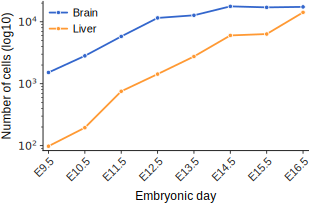

In [5]:
time_sequence_analysis.count_cell_number(recompute=True, font_size=12)
display_svg(time_output_path / "cell_number_over_stages" / "cell_number_over_stages.svg")

## Step 6 — Edge number over stages

In [6]:
time_sequence_analysis.count_edge_number(recompute=True, font_size=12)
display_svg_grid(sorted((time_output_path / "edge_number_over_stages").glob("*.svg")), n_cols=2)

[TimeSeriesMetrics] Processing stage 9.5 (1/8)...
[TimeSeriesMetrics] Processing stage 10.5 (2/8)...
[TimeSeriesMetrics] Processing stage 11.5 (3/8)...
[TimeSeriesMetrics] Processing stage 12.5 (4/8)...
[TimeSeriesMetrics] Processing stage 13.5 (5/8)...
[TimeSeriesMetrics] Processing stage 14.5 (6/8)...
[TimeSeriesMetrics] Processing stage 15.5 (7/8)...
[TimeSeriesMetrics] Processing stage 16.5 (8/8)...
[TimeSeriesMetrics] Organ Brain: ['F2-F2r', 'Lpar3-Adgre5', 'Nts-Sort1', 'Plg-Pard3', 'Thbs4-Cd36']
[TimeSeriesMetrics] Organ Liver: ['F2-F2r', 'Lpar3-Adgre5', 'Nts-Sort1', 'Plg-Pard3', 'Thbs4-Cd36']
[TimeSeriesMetrics] Plot saved: /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/edge_number_over_stages/edge_number_over_stages_Brain.svg
[TimeSeriesMetrics] Edge-number plot for Brain saved to /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/edge_number_over_stages/edge_number_over_stages_Brain.svg
[TimeSeriesMetrics] Plot saved: /home/wangshu

,


## Step 7 — Efficiency metrics

  Spatial metrics: 9.5 / Brain (n_cells=1518) ...
  Spatial metrics: 9.5 / Liver (n_cells=98) ...
  Spatial metrics: 10.5 / Brain (n_cells=2816) ...
  Spatial metrics: 10.5 / Liver (n_cells=195) ...
  Spatial metrics: 11.5 / Brain (n_cells=5794) ...
  Spatial metrics: 11.5 / Liver (n_cells=754) ...
  Spatial metrics: 12.5 / Brain (n_cells=11525) ...
  Spatial metrics: 12.5 / Liver (n_cells=1429) ...
  Spatial metrics: 13.5 / Brain (n_cells=12707) ...
  Spatial metrics: 13.5 / Liver (n_cells=2750) ...
  Spatial metrics: 14.5 / Brain (n_cells=17715) ...
  Spatial metrics: 14.5 / Liver (n_cells=6015) ...
  Spatial metrics: 15.5 / Brain (n_cells=17071) ...
  Spatial metrics: 15.5 / Liver (n_cells=6337) ...
  Spatial metrics: 16.5 / Brain (n_cells=17374) ...
  Spatial metrics: 16.5 / Liver (n_cells=14167) ...
[Efficiency] Metrics figure saved to /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/efficiency_metrics/efficiency_metrics.svg.


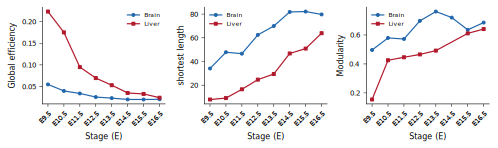

In [7]:
time_sequence_analysis.plot_efficiency_metrics(recompute=True, region_lr_map=region_lr_map, font_size=8)
display_svg(time_output_path / "efficiency_metrics" / "efficiency_metrics.svg")

## Step 8 — Cell-type strength over stages

In [8]:
time_sequence_analysis.plot_celltype_strength_bars(recompute=True, region_lr_map=region_lr_map, font_size=8)
display_svg_grid(sorted((time_output_path / "celltype_strength_over_stages").glob("*.svg")), n_cols=2)

[CellTypeStrengthOverStages] Aggregate: 9.5 / Brain / Nts-Sort1
[CellTypeStrengthOverStages] Aggregate: 9.5 / Liver / F2-F2r
[CellTypeStrengthOverStages] Aggregate: 10.5 / Brain / Nts-Sort1
[CellTypeStrengthOverStages] Aggregate: 10.5 / Liver / F2-F2r
[CellTypeStrengthOverStages] Aggregate: 11.5 / Brain / Nts-Sort1
[CellTypeStrengthOverStages] Aggregate: 11.5 / Liver / F2-F2r
[CellTypeStrengthOverStages] Aggregate: 12.5 / Brain / Nts-Sort1
[CellTypeStrengthOverStages] Aggregate: 12.5 / Liver / F2-F2r
[CellTypeStrengthOverStages] Aggregate: 13.5 / Brain / Nts-Sort1
[CellTypeStrengthOverStages] Aggregate: 13.5 / Liver / F2-F2r
[CellTypeStrengthOverStages] Aggregate: 14.5 / Brain / Nts-Sort1
[CellTypeStrengthOverStages] Aggregate: 14.5 / Liver / F2-F2r
[CellTypeStrengthOverStages] Aggregate: 15.5 / Brain / Nts-Sort1
[CellTypeStrengthOverStages] Aggregate: 15.5 / Liver / F2-F2r
[CellTypeStrengthOverStages] Aggregate: 16.5 / Brain / Nts-Sort1
[CellTypeStrengthOverStages] Aggregate: 16.5 / L

,


## Step 9 — Graph density over stages

In [9]:
time_sequence_analysis.plot_graph_density_over_stages(recompute=True, font_size=12)
display_svg_grid(sorted((time_output_path / "graph_density_over_stages").glob("*.svg")), n_cols=2)

[TimeSeriesDensity] Processing stage 9.5 (1/8)...
[TimeSeriesDensity] Processing stage 10.5 (2/8)...
[TimeSeriesDensity] Processing stage 11.5 (3/8)...
[TimeSeriesDensity] Processing stage 12.5 (4/8)...
[TimeSeriesDensity] Processing stage 13.5 (5/8)...
[TimeSeriesDensity] Processing stage 14.5 (6/8)...
[TimeSeriesDensity] Processing stage 15.5 (7/8)...
[TimeSeriesDensity] Processing stage 16.5 (8/8)...
[TimeSeriesDensity] Density figure saved for Brain -> /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/graph_density_over_stages/density_over_stages_Brain.svg
[TimeSeriesDensity] Density figure saved for Liver -> /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/graph_density_over_stages/density_over_stages_Liver.svg
[TimeSeriesDensity] Density curves saved under /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/graph_density_over_stages.


,


## Step 10 — Strong nodes over stages

[StrongNodesOverStages] Strong-node curves figure saved to /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/strong_nodes_over_stages/strong_nodes_over_stages.svg.


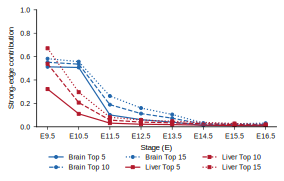

In [10]:
time_sequence_analysis.plot_strong_nodes_over_stages(recompute=True, region_lr_map=region_lr_map, font_size=8)
display_svg(time_output_path / "strong_nodes_over_stages" / "strong_nodes_over_stages.svg")

## Step 11 — Strength vs spatial distance

In [11]:
time_sequence_analysis.plot_strength_vs_distance_over_stages(recompute=True, region_lr_map=region_lr_map, font_size=12)
display_svg_grid(sorted((time_output_path / "strength_vs_distance_over_stages").glob("*.svg")), n_cols=2)

[StrengthDistance] Figure saved for Brain -> /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/strength_vs_distance_over_stages/strength_vs_distance_Brain.svg
[StrengthDistance] Figure saved for Liver -> /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/strength_vs_distance_over_stages/strength_vs_distance_Liver.svg
[StrengthDistance] Strength–distance figures saved under /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/strength_vs_distance_over_stages.


,


## Step 12 — CCDF degree and strength

Load: 9.5 / Brain / Nts-Sort1 ...
Load: 9.5 / Liver / F2-F2r ...
Load: 10.5 / Brain / Nts-Sort1 ...
Load: 10.5 / Liver / F2-F2r ...
Load: 11.5 / Brain / Nts-Sort1 ...
Load: 11.5 / Liver / F2-F2r ...
Load: 12.5 / Brain / Nts-Sort1 ...
Load: 12.5 / Liver / F2-F2r ...
Load: 13.5 / Brain / Nts-Sort1 ...
Load: 13.5 / Liver / F2-F2r ...
Load: 14.5 / Brain / Nts-Sort1 ...
Load: 14.5 / Liver / F2-F2r ...
Load: 15.5 / Brain / Nts-Sort1 ...
Load: 15.5 / Liver / F2-F2r ...
Load: 16.5 / Brain / Nts-Sort1 ...
Load: 16.5 / Liver / F2-F2r ...
[CCDF] CCDF degree/strength figure saved to /home/wangshuai/project/CellSTIC/data/mouse_embryo/analysis/time_series/ccdf_degree_strength/ccdf_degree_strength.svg.


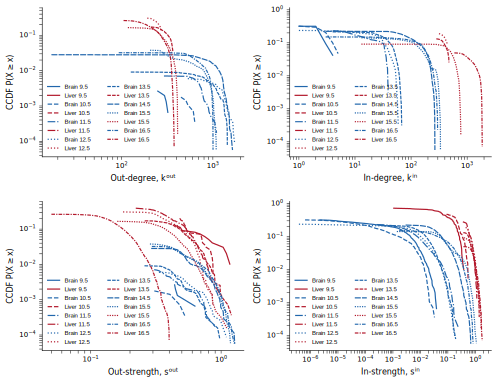

In [12]:
time_sequence_analysis.plot_ccdf_degree_strength(recompute=True, region_lr_map=region_lr_map, font_size=8)
display_svg(time_output_path / "ccdf_degree_strength" / "ccdf_degree_strength.svg")